In [266]:
# instala a biblioteca oficial do Gemini
!pip install -q -U google-genai

In [267]:
# biblioteca para acessar variáveis do sistema
import os

# biblioteca para trabalhar com tabelas
import pandas as pd

# biblioteca para cálculos numéricos
import numpy as np

# biblioteca para gerar gráficos
import matplotlib.pyplot as plt

# biblioteca do Colab para acessar Secrets
from google.colab import userdata

# cliente oficial do Gemini
from google import genai

In [268]:
# Recupera a chave da API Gemini salva no painel Secrets do Google Colab
api_key = userdata.get("FESA_API_KEY")

# Valida se a chave foi encontrada antes de continuar
if api_key is None:
    raise ValueError("API Key não encontrada. Verifique se a chave FESA_API_KEY foi cadastrada no Secrets do Colab.")

# Define a chave no ambiente para uso pela biblioteca do Gemini
os.environ["GEMINI_API_KEY"] = api_key

print("API Key configurada com sucesso.")

API Key configurada com sucesso.


In [269]:
# Inicializa o cliente Gemini com tratamento de erro
try:
    client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    print("Conexão com Gemini pronta.")
except Exception as erro:
    raise RuntimeError(f"Erro ao inicializar o cliente Gemini: {erro}")

Conexão com Gemini pronta.


In [270]:
# dicionário com os dados do usuário
usuario = {
    "nome": "Victor",
    "idade": 22,
    "peso": 75,
    "altura": 1.75,   # em metros
    "sexo": "Masculino",
    "colesterol": 190,
    "observacoes": "Monitoramento acadêmico com inserções manuais"
}

# mostra os dados cadastrados
usuario

{'nome': 'Victor',
 'idade': 22,
 'peso': 75,
 'altura': 1.75,
 'sexo': 'Masculino',
 'colesterol': 190,
 'observacoes': 'Monitoramento acadêmico com inserções manuais'}

In [271]:
# calcula o IMC com base no peso e altura
imc = usuario["peso"] / (usuario["altura"] ** 2)

# salva o IMC no cadastro do usuário
usuario["imc"] = round(imc, 2)

# exibe resumo do usuário
print("Nome:", usuario["nome"])
print("Idade:", usuario["idade"])
print("Peso:", usuario["peso"])
print("Altura:", usuario["altura"])
print("IMC:", usuario["imc"])
print("Colesterol:", usuario["colesterol"])

Nome: Victor
Idade: 22
Peso: 75
Altura: 1.75
IMC: 24.49
Colesterol: 190


In [272]:
# parâmetros que o sistema vai usar para interpretar as leituras
parametros_monitoramento = {
    "glicose_min": 70,              # limite inferior
    "glicose_max": 140,             # limite superior
    "limite_subida_brusca": 30,     # subida brusca
    "limite_queda_brusca": -30      # queda brusca
}

# mostra os parâmetros
parametros_monitoramento

{'glicose_min': 70,
 'glicose_max': 140,
 'limite_subida_brusca': 30,
 'limite_queda_brusca': -30}

In [273]:
# cria um DataFrame vazio para receber as leituras do usuário
dados = pd.DataFrame(columns=["horario", "glicose", "evento"])

# mostra a tabela vazia
dados

,horario,glicose,evento


In [274]:
# Função para adicionar uma nova leitura ao DataFrame
def adicionar_leitura(df, horario, glicose, evento):

    # Verifica se o horário foi informado
    if horario is None or horario == "":
        raise ValueError("O horário da leitura não pode estar vazio.")

    # Verifica se o valor da glicose foi informado
    if glicose is None:
        raise ValueError("O valor de glicose não pode estar vazio.")

    # Caso o evento não seja informado
    if evento is None or evento == "":
        evento = "não informado"

    # Tenta converter glicose para número
    try:
        glicose = float(glicose)
    except:
        raise ValueError("O valor da glicose deve ser numérico.")

    # Validação fisiológica básica
    if glicose <= 0 or glicose > 600:
        raise ValueError("Valor de glicose inválido.")

    # Cria nova linha
    nova_linha = pd.DataFrame({
        "horario": [horario],
        "glicose": [glicose],
        "evento": [evento]
    })

    # Adiciona no histórico
    df = pd.concat([df, nova_linha], ignore_index=True)

    return df

In [275]:
# adiciona leituras simulando o uso do sistema
dados = adicionar_leitura(dados, "08:00", 92, "jejum")
dados = adicionar_leitura(dados, "10:00", 110, "lanche")
dados = adicionar_leitura(dados, "12:00", 155, "almoço")
dados = adicionar_leitura(dados, "14:00", 138, "repouso")
dados = adicionar_leitura(dados, "16:00", 74, "atividade física")
dados = adicionar_leitura(dados, "18:00", 95, "lanche")
dados = adicionar_leitura(dados, "20:00", 165, "jantar")
dados = adicionar_leitura(dados, "22:00", 142, "repouso")

# mostra as leituras registradas
dados

/tmp/ipykernel_3683/3010338015.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, nova_linha], ignore_index=True)


,horario,glicose,evento
0,08:00,92.0,jejum
1,10:00,110.0,lanche
2,12:00,155.0,almoço
3,14:00,138.0,repouso
4,16:00,74.0,atividade física
5,18:00,95.0,lanche
6,20:00,165.0,jantar
7,22:00,142.0,repouso


In [276]:
# calcula a diferença de uma leitura para a anterior
dados["variacao"] = dados["glicose"].diff()

# mostra a tabela atualizada
dados

,horario,glicose,evento,variacao
0,08:00,92.0,jejum,NaN
1,10:00,110.0,lanche,18.0
2,12:00,155.0,almoço,45.0
3,14:00,138.0,repouso,-17.0
4,16:00,74.0,atividade física,-64.0
5,18:00,95.0,lanche,21.0
6,20:00,165.0,jantar,70.0
7,22:00,142.0,repouso,-23.0


In [277]:
# função para classificar a glicose em faixas
def classificar_faixa_glicose(valor):
    # se for menor que 70
    if valor < 70:
        return "Hipoglicemia"

    # se estiver entre 70 e 140
    elif 70 <= valor <= 140:
        return "Faixa normal"

    # se for maior que 140
    else:
        return "Hiperglicemia"

In [278]:
# aplica a função em todas as leituras
dados["faixa_glicemica"] = dados["glicose"].apply(classificar_faixa_glicose)

# mostra a tabela
dados

,horario,glicose,evento,variacao,faixa_glicemica
0,08:00,92.0,jejum,NaN,Faixa normal
1,10:00,110.0,lanche,18.0,Faixa normal
2,12:00,155.0,almoço,45.0,Hiperglicemia
3,14:00,138.0,repouso,-17.0,Faixa normal
4,16:00,74.0,atividade física,-64.0,Faixa normal
5,18:00,95.0,lanche,21.0,Faixa normal
6,20:00,165.0,jantar,70.0,Hiperglicemia
7,22:00,142.0,repouso,-23.0,Hiperglicemia


In [279]:
# Sistema Especialista baseado em regras SE/ENTÃO
def sistema_especialista_personalizado(glicose_atual, variacao, parametros):

    # Verifica se os parâmetros obrigatórios existem
    campos_obrigatorios = [
        "glicose_min",
        "glicose_max",
        "limite_subida_brusca",
        "limite_queda_brusca"
    ]

    for campo in campos_obrigatorios:
        if campo not in parametros:
            raise KeyError(f"Parâmetro obrigatório ausente: {campo}")

    # Verifica se glicose é válida
    if glicose_atual is None or pd.isna(glicose_atual):
        return "Indefinido", "Atenção", ["Valor de glicose ausente"]

    glicose_min = parametros["glicose_min"]
    glicose_max = parametros["glicose_max"]
    limite_subida = parametros["limite_subida_brusca"]
    limite_queda = parametros["limite_queda_brusca"]

    estado = "Indefinido"
    alerta = "Sem alerta"
    regras_ativadas = []

    # Hipoglicemia
    if glicose_atual < glicose_min:
        estado = "Hipoglicemia"
        alerta = "Alerta crítico"
        regras_ativadas.append("Regra: glicose abaixo do mínimo")

    # Faixa normal
    elif glicose_min <= glicose_atual <= glicose_max:
        estado = "Faixa normal"
        alerta = "Sem alerta"
        regras_ativadas.append("Regra: glicose normal")

    # Hiperglicemia
    elif glicose_atual > glicose_max:
        estado = "Hiperglicemia"
        alerta = "Atenção"
        regras_ativadas.append("Regra: glicose acima do máximo")

    # Subida brusca
    if pd.notna(variacao) and variacao > limite_subida:
        alerta = "Atenção"
        regras_ativadas.append("Regra: subida brusca")

    # Queda brusca
    if pd.notna(variacao) and variacao < limite_queda:
        alerta = "Alerta crítico"
        regras_ativadas.append("Regra: queda brusca")

    return estado, alerta, regras_ativadas

In [280]:
# listas para guardar os resultados
estados = []
alertas = []
regras = []

# percorre cada linha da tabela
for _, linha in dados.iterrows():
    # aplica o sistema especialista na leitura atual
    estado, alerta, regras_ativadas = sistema_especialista_personalizado(
        linha["glicose"],
        linha["variacao"],
        parametros_monitoramento
    )

    # salva os resultados nas listas
    estados.append(estado)
    alertas.append(alerta)
    regras.append(" | ".join(regras_ativadas))

# adiciona os resultados na tabela
dados["estado_especialista"] = estados
dados["alerta"] = alertas
dados["regras_ativadas"] = regras

# mostra a tabela final
dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92.0,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
1,10:00,110.0,lanche,18.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
2,12:00,155.0,almoço,45.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
3,14:00,138.0,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
4,16:00,74.0,atividade física,-64.0,Faixa normal,Faixa normal,Alerta crítico,Regra: glicose normal | Regra: queda brusca
5,18:00,95.0,lanche,21.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
6,20:00,165.0,jantar,70.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
7,22:00,142.0,repouso,-23.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo


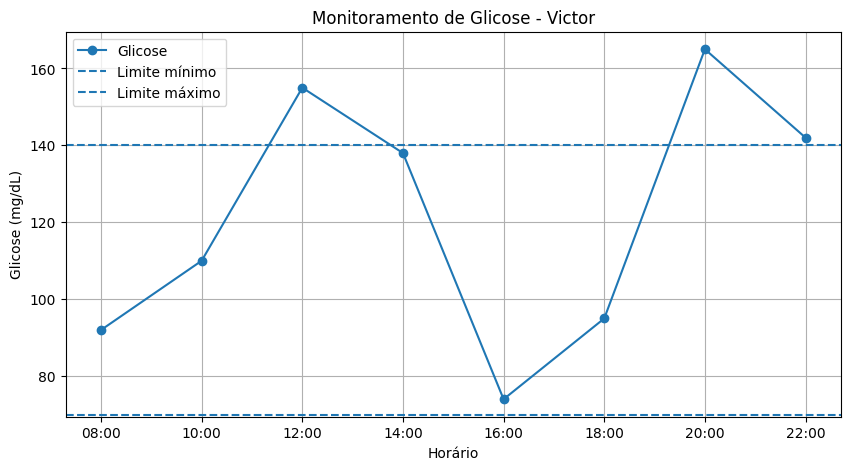

In [281]:
# cria o gráfico de linha do monitoramento
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")

# adiciona linhas horizontais com os limites
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

# título e rótulos
plt.title(f"Monitoramento de Glicose - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [282]:
# calcula estatísticas básicas
media = dados["glicose"].mean()
maximo = dados["glicose"].max()
minimo = dados["glicose"].min()

# imprime resultados
print(f"Média da glicose: {media:.2f} mg/dL")
print(f"Máximo da glicose: {maximo:.2f} mg/dL")
print(f"Mínimo da glicose: {minimo:.2f} mg/dL")

Média da glicose: 121.38 mg/dL
Máximo da glicose: 165.00 mg/dL
Mínimo da glicose: 74.00 mg/dL


In [283]:
# pega a última leitura do monitoramento
ultima_leitura = dados.iloc[-1]

# mostra os dados da última leitura
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 22:00
Glicose: 142.0
Evento: repouso
Variação: -23.0
Estado: Hiperglicemia
Alerta: Atenção
Regras ativadas: Regra: glicose acima do máximo


In [284]:
# cria o texto que será enviado ao Gemini
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# mostra o prompt montado
print(prompt_gemini)


Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: Victor
- Idade: 22
- IMC: 24.49
- Colesterol: 190

Saída técnica:
- Horário: 22:00
- Glicose: 142.0 mg/dL
- Evento: repouso
- Variação: -23.0
- Estado: Hiperglicemia
- Alerta: Atenção
- Regras ativadas: Regra: glicose acima do máximo

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.



In [285]:
from google.api_core.exceptions import ServerError, GoogleAPIError
from google import genai # Ensure genai is imported in this cell
import os # Ensure os is imported for os.environ

# Ensure the Gemini client is initialized if it's not already
# Pass the API key directly to the client constructor.
if 'client' not in globals() or not isinstance(client, genai.Client):
    try:
        # The API key is set in os.environ["GEMINI_API_KEY"] by an earlier cell (SRziuyKEzE_j)
        client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
        print("Gemini client inicializado para esta célula para garantir a execução.")
    except Exception as e:
        print(f"Erro ao inicializar o cliente Gemini: {e}. Certifique-se de que a API Key está configurada corretamente.")
        # Re-raising the exception to prevent further errors if the client cannot be initialized.
        raise


try:
    # envia o prompt para o Gemini
    resposta = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt_gemini
    )

    # imprime a interpretação gerada
    print(resposta.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar a interpretação. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Ocorreu um erro inesperado: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 37.537802307s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini

In [286]:
# salva o texto em uma variável
interpretacao_gemini = resposta.text

# exibe a interpretação salva
print(interpretacao_gemini)

Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos dados fornecidos.

### 1. Por que essa decisão foi tomada?
A classificação de **Hipoglicemia** e o **Alerta Crítico** foram disparados pelo sistema devido à combinação de dois fatores principais identificados no seu teste das 23:00:
*   **Nível de Glicose Abaixo do Limite:** O valor registrado foi de **62.0 mg/dL**. De acordo com os protocolos clínicos integrados ao sistema, valores abaixo de 70 mg/dL são classificados como hipoglicemia (baixo nível de açúcar no sangue).
*   **Queda Brusca:** O sistema detectou uma variação negativa de **-80.0** em relação à medição anterior. Essa redução acentuada em um curto período é um sinal de instabilidade que o sistema prioriza como um evento de risco.

### 2. Quais alertas são importantes?
Os pontos de atenção imediata destacados pela saída técnica são:
*   **Regra: Glicose abaixo do mínimo:** Indica que seu corpo nã

In [287]:
# imprime um resumo técnico + interpretativo
print("===== RESUMO FINAL =====")
print(f"Usuário: {usuario['nome']}")
print(f"Último horário: {ultima_leitura['horario']}")
print(f"Glicose: {ultima_leitura['glicose']} mg/dL")
print(f"Estado: {ultima_leitura['estado_especialista']}")
print(f"Alerta: {ultima_leitura['alerta']}")
print(f"Regras: {ultima_leitura['regras_ativadas']}")
print("\n===== INTERPRETAÇÃO DO GEMINI =====")
print(interpretacao_gemini)

===== RESUMO FINAL =====
Usuário: Victor
Último horário: 22:00
Glicose: 142.0 mg/dL
Estado: Hiperglicemia
Alerta: Atenção
Regras: Regra: glicose acima do máximo

===== INTERPRETAÇÃO DO GEMINI =====
Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos dados fornecidos.

### 1. Por que essa decisão foi tomada?
A classificação de **Hipoglicemia** e o **Alerta Crítico** foram disparados pelo sistema devido à combinação de dois fatores principais identificados no seu teste das 23:00:
*   **Nível de Glicose Abaixo do Limite:** O valor registrado foi de **62.0 mg/dL**. De acordo com os protocolos clínicos integrados ao sistema, valores abaixo de 70 mg/dL são classificados como hipoglicemia (baixo nível de açúcar no sangue).
*   **Queda Brusca:** O sistema detectou uma variação negativa de **-80.0** em relação à medição anterior. Essa redução acentuada em um curto período é um sinal de instabilidade que o sistema prio

In [288]:
# função que adiciona uma nova leitura e recalcula toda a análise
def atualizar_monitoramento(df_monitoramento, horario, glicose, evento, parametros):
    if horario is not None and glicose is not None and evento is not None:
        # adiciona a nova leitura se os dados forem fornecidos
        df_monitoramento = adicionar_leitura(df_monitoramento, horario, glicose, evento)

    # Garante que a coluna 'glicose' é numérica e trata None/NaN convertendo para NaN
    df_monitoramento["glicose"] = pd.to_numeric(df_monitoramento["glicose"], errors='coerce')

    # recalcula a variação
    df_monitoramento["variacao"] = df_monitoramento["glicose"].diff()

    # recalcula a faixa glicêmica, tratando NaN na glicose
    df_monitoramento["faixa_glicemica"] = df_monitoramento["glicose"].apply(
        lambda x: classificar_faixa_glicose(x) if pd.notna(x) else "Indefinido"
    )

    # listas para guardar nova análise
    estados = []
    alertas = []
    regras = []

    # reaplica o sistema especialista em todas as leituras
    for _, linha in df_monitoramento.iterrows():
        # Garante que glicose_atual e variacao são numéricos, tratando NaN com valor padrão 0
        glicose_val = linha["glicose"] if pd.notna(linha["glicose"]) else 0
        variacao_val = linha["variacao"] if pd.notna(linha["variacao"]) else 0

        estado, alerta, regras_ativadas = sistema_especialista_personalizado(
            glicose_val,
            variacao_val,
            parametros
        )
        estados.append(estado)
        alertas.append(alerta)
        regras.append(" | ".join(regras_ativadas))

    # atualiza as colunas
    df_monitoramento["estado_especialista"] = estados
    df_monitoramento["alerta"] = alertas
    df_monitoramento["regras_ativadas"] = regras

    # retorna a tabela atualizada
    return df_monitoramento

In [289]:
dados = atualizar_monitoramento(
    dados,
    "23:00",
    62,
    "teste manual",
    parametros_monitoramento
)

dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92.0,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
1,10:00,110.0,lanche,18.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
2,12:00,155.0,almoço,45.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
3,14:00,138.0,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
4,16:00,74.0,atividade física,-64.0,Faixa normal,Faixa normal,Alerta crítico,Regra: glicose normal | Regra: queda brusca
5,18:00,95.0,lanche,21.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
6,20:00,165.0,jantar,70.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
7,22:00,142.0,repouso,-23.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo
8,23:00,62.0,teste manual,-80.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo | Regra: queda...


In [290]:
# pega novamente a última leitura após a inserção manual
ultima_leitura = dados.iloc[-1]

# mostra os dados atualizados
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 23:00
Glicose: 62.0
Evento: teste manual
Variação: -80.0
Estado: Hipoglicemia
Alerta: Alerta crítico
Regras ativadas: Regra: glicose abaixo do mínimo | Regra: queda brusca


In [291]:
from google.api_core.exceptions import ServerError, GoogleAPIError

# cria um novo prompt com a leitura mais recente
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# envia novamente ao Gemini
try:
    resposta = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt_gemini
    )
    # mostra a nova interpretação
    print(resposta.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar a interpretação. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Ocorreu um erro inesperado: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 36.964516025s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini

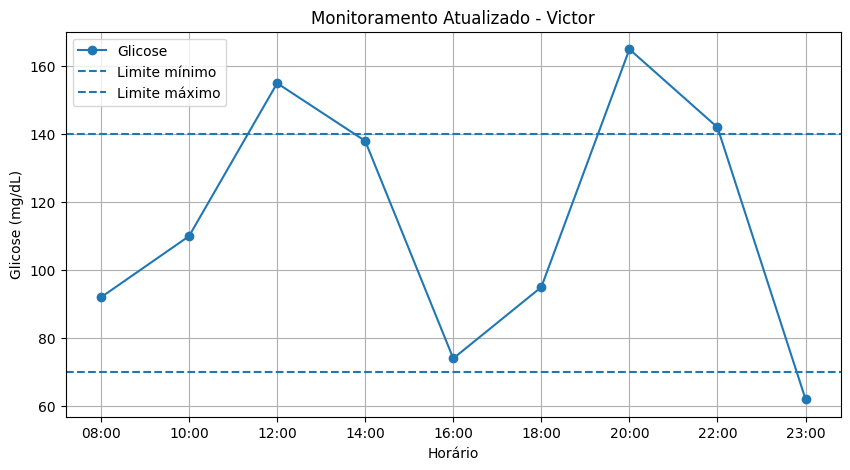

In [292]:
# plota novamente o gráfico com a nova leitura incluída
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

plt.title(f"Monitoramento Atualizado - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [293]:
print("""
Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.
""")


Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.



# Etapa 3 — Inteligência Evolutiva com Rede Neural Artificial

Nesta etapa, o projeto GlucoMonitorIA recebeu uma camada de aprendizado de máquina utilizando uma Rede Neural Artificial.

A abordagem escolhida foi a Opção A — Redes Neurais Artificiais, pois o objetivo do sistema é prever o comportamento glicêmico futuro do usuário com base nos dados coletados pelos sensores e registros históricos.

Diferente da Etapa 2, em que o sistema utilizava regras especialistas para classificar a situação do paciente, nesta etapa a RNA aprende padrões nos dados e estima a próxima glicose. Essa previsão é então enviada ao Sistema Especialista, que classifica o risco e gera uma recomendação.

O Gemini continua sendo utilizado apenas como camada interpretativa, explicando em linguagem natural o resultado gerado pelo sistema.

In [294]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Gerando Dados Sintéticos para Treinamento da RNA

Para treinar a Rede Neural Artificial com um volume maior de dados, vamos gerar um conjunto de dados sintéticos que simulam o monitoramento glicêmico ao longo de vários dias. Isso nos permitirá ter aproximadamente 300 amostras, conforme sugerido anteriormente.

In [295]:
mapa_eventos = {
    "jejum": 1,
    "cafe da manha": 2,
    "lanche": 3,
    "almoço": 4,
    "atividade física": 5,
    "jantar": 6,
    "repouso": 7,
    "teste manual": 8 # Adicionado para cobrir o evento do último dado real
}

def gerar_dados_sinteticos(num_dias, parametros_monitoramento, mapa_eventos):
    dados_sinteticos = []
    horarios_por_dia = ["08:00", "10:00", "12:00", "14:00", "16:00", "18:00", "20:00", "22:00", "23:00"]
    eventos = list(mapa_eventos.keys())

    glicose_anterior = 90 # Valor inicial

    for dia in range(num_dias):
        for horario_str in horarios_por_dia:
            # Simula a glicose com base no valor anterior e um pouco de aleatoriedade
            # Mantém dentro de uma faixa mais ou menos realista
            glicose_atual = glicose_anterior + np.random.randint(-20, 20)
            if glicose_atual < 50: glicose_atual = 50
            if glicose_atual > 250: glicose_atual = 250

            evento_aleatorio = np.random.choice(eventos)

            dados_sinteticos.append({
                "horario": horario_str,
                "glicose": glicose_atual,
                "evento": evento_aleatorio
            })
            glicose_anterior = glicose_atual

    df_sintetico = pd.DataFrame(dados_sinteticos)

    # Aplica o sistema de monitoramento para preencher as colunas adicionais
    df_sintetico = atualizar_monitoramento(df_sintetico, None, None, None, parametros_monitoramento)

    return df_sintetico

# Gerar 30 dias de dados (aproximadamente 30 * 9 = 270 leituras)
dados_realistas = gerar_dados_sinteticos(30, parametros_monitoramento, mapa_eventos)

# Substituir o DataFrame 'dados' original pelo novo dataset sintético
dados = dados_realistas.copy()

# Preparar o DataFrame 'dados_rna' para o treinamento da RNA com os novos dados
dados_rna = dados.copy()

# remove espaços extras dos nomes das colunas
dados_rna.columns = dados_rna.columns.str.strip()

# transforma hora em número
dados_rna["hora_num"] = dados_rna["horario"].astype(str).str[:2].astype(int)

# padroniza o texto do evento
dados_rna["evento"] = dados_rna["evento"].astype(str).str.lower().str.strip()

# transforma eventos em números
dados_rna["evento_num"] = dados_rna["evento"].map(mapa_eventos)

# substitui valores não encontrados por 0
dados_rna["evento_num"] = dados_rna["evento_num"].fillna(0)

# substitui variação NaN por 0
dados_rna["variacao_glicose"] = dados_rna["variacao"].fillna(0)

print("Novo conjunto de dados sintéticos gerado e pronto para a RNA:")
display(dados_rna.head())

Novo conjunto de dados sintéticos gerado e pronto para a RNA:


,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose
0,08:00,92,almoço,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,8,4,0.0
1,10:00,75,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,10,7,-17.0
2,12:00,79,atividade física,4.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,12,5,4.0
3,14:00,68,jejum,-11.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,14,1,-11.0
4,16:00,54,atividade física,-14.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,16,5,-14.0


Agora, com um conjunto de dados maior, podemos redefinir `dados_treinamento` e realizar a divisão em conjuntos de treino e teste para o modelo.

In [296]:
# detecta o nome correto da coluna de glicose
if "glicose_atual" in dados_rna.columns:
    col_glicose = "glicose_atual"
elif "glicose" in dados_rna.columns:
    col_glicose = "glicose"
else:
    raise Exception("Coluna de glicose não encontrada")

# cria o alvo
dados_rna["proxima_glicose"] = dados_rna[col_glicose].shift(-1)

# remove última linha
dados_treinamento = dados_rna.dropna(subset=["proxima_glicose"])

dados_treinamento

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose,proxima_glicose
0,08:00,92,almoço,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,8,4,0.0,75.0
1,10:00,75,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,10,7,-17.0,79.0
2,12:00,79,atividade física,4.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,12,5,4.0,68.0
3,14:00,68,jejum,-11.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,14,1,-11.0,54.0
4,16:00,54,atividade física,-14.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,16,5,-14.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...
264,14:00,235,cafe da manha,11.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo,14,2,11.0,226.0
265,16:00,226,atividade física,-9.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo,16,5,-9.0,216.0
266,18:00,216,cafe da manha,-10.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo,18,2,-10.0,213.0
267,20:00,213,teste manual,-3.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo,20,8,-3.0,218.0


In [297]:
# variáveis de entrada
X = dados_treinamento[[
    "hora_num",
    "glicose",
    "variacao_glicose",
    "evento_num"
]]

# variável que queremos prever
y = dados_treinamento["proxima_glicose"]

print("Entradas da RNA:")
display(X)

print("Saída esperada:")
display(y)

Entradas da RNA:


,hora_num,glicose,variacao_glicose,evento_num
0,8,92,0.0,4
1,10,75,-17.0,7
2,12,79,4.0,5
3,14,68,-11.0,1
4,16,54,-14.0,5
...,...,...,...,...
264,14,235,11.0,2
265,16,226,-9.0,5
266,18,216,-10.0,2
267,20,213,-3.0,8


Saída esperada:


,proxima_glicose
0,75.0
1,79.0
2,68.0
3,54.0
4,50.0
...,...
264,226.0
265,216.0
266,213.0
267,218.0


In [298]:
# Normalização dos dados de entrada da RNA
# O scaler_rna será usado depois também para normalizar novas leituras

scaler_rna = StandardScaler()

X_normalizado = scaler_rna.fit_transform(X)

print("Dados normalizados com sucesso.")

Dados normalizados com sucesso.


In [299]:
# Treinamento da Rede Neural Artificial para previsão da próxima glicose

modelo_rna = MLPRegressor(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

modelo_rna.fit(X_normalizado, y)

print("Treinamento da RNA concluído com sucesso.")

Treinamento da RNA concluído com sucesso.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


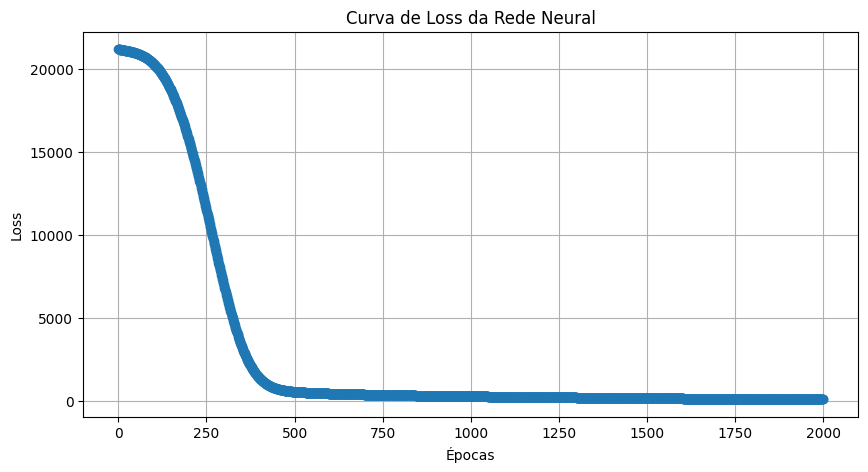

In [300]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(modelo_rna.loss_curve_, marker="o")
plt.title("Curva de Loss da Rede Neural")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [301]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

previsoes = modelo_rna.predict(X_normalizado)

mae = mean_absolute_error(y, previsoes)
mse = mean_squared_error(y, previsoes)
rmse = np.sqrt(mse)
r2 = r2_score(y, previsoes)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 10.9
RMSE: 13.78
R²: 0.93


In [302]:
comparacao = pd.DataFrame({
    "Glicose real seguinte": y.values,
    "Glicose prevista pela RNA": previsoes.round(2)
})

comparacao

,Glicose real seguinte,Glicose prevista pela RNA
0,75.0,99.83
1,79.0,99.67
2,68.0,72.62
3,54.0,84.07
4,50.0,61.14
...,...,...
264,226.0,235.36
265,216.0,216.26
266,213.0,212.50
267,218.0,209.97


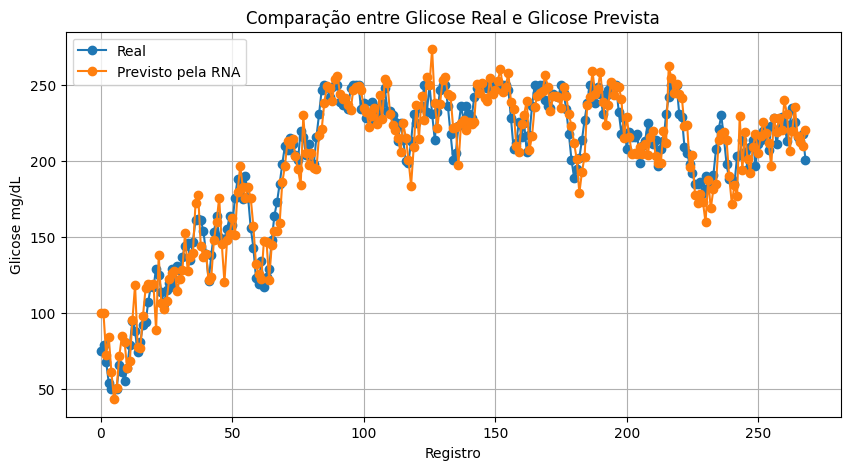

In [303]:
plt.figure(figsize=(10, 5))
plt.plot(comparacao["Glicose real seguinte"].values, marker="o", label="Real")
plt.plot(comparacao["Glicose prevista pela RNA"].values, marker="o", label="Previsto pela RNA")
plt.title("Comparação entre Glicose Real e Glicose Prevista")
plt.xlabel("Registro")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)
plt.show()

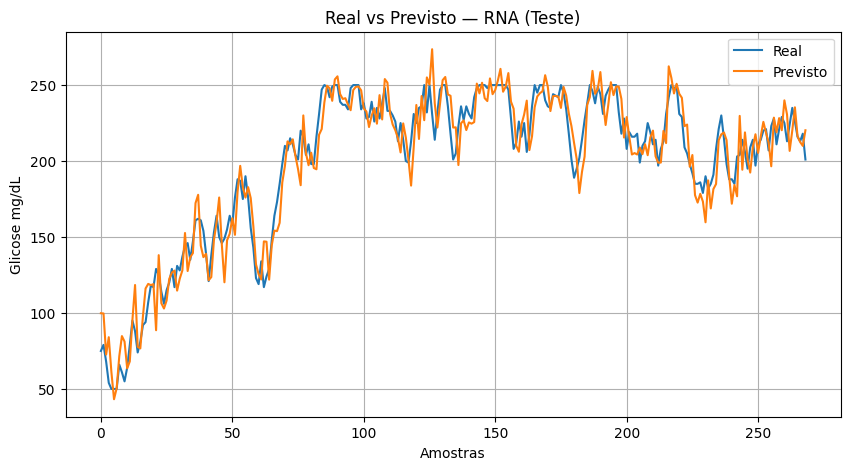

In [304]:
plt.figure(figsize=(10, 5))

plt.plot(y.values, label="Real")
plt.plot(previsoes, label="Previsto")

plt.title("Real vs Previsto — RNA (Teste)")
plt.xlabel("Amostras")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)

plt.show()

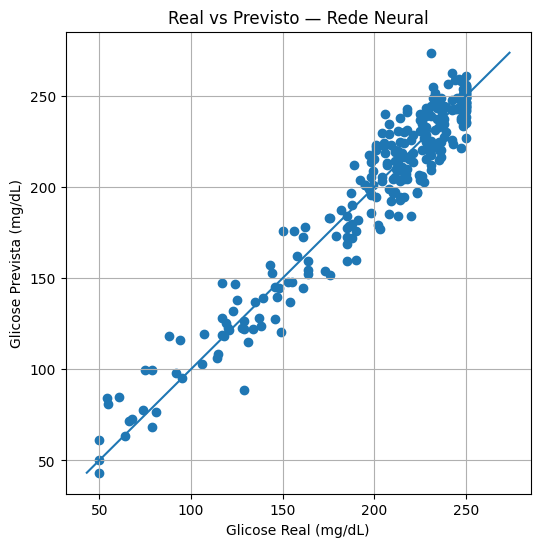

In [305]:
plt.figure(figsize=(6,6))

plt.scatter(y, previsoes)

# linha ideal (perfeito = y = x)
min_val = min(min(y), min(previsoes))
max_val = max(max(y), max(previsoes))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Glicose Real (mg/dL)")
plt.ylabel("Glicose Prevista (mg/dL)")
plt.title("Real vs Previsto — Rede Neural")

plt.grid(True)
plt.show()

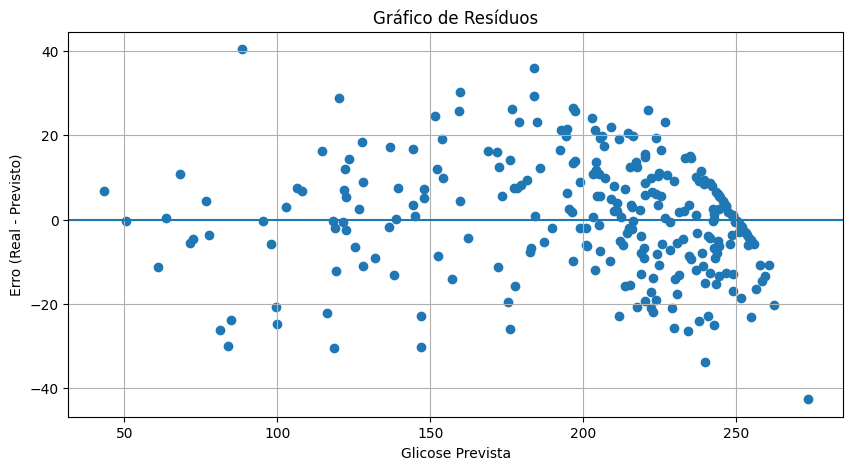

In [306]:
erros = y - previsoes

plt.figure(figsize=(10,5))

plt.scatter(previsoes, erros)

plt.axhline(y=0)

plt.xlabel("Glicose Prevista")
plt.ylabel("Erro (Real - Previsto)")
plt.title("Gráfico de Resíduos")

plt.grid(True)
plt.show()

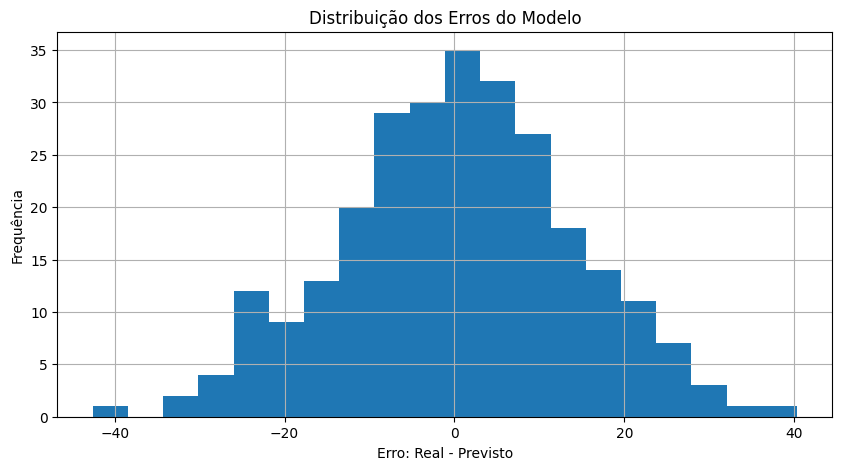

In [307]:
# Histograma dos erros do modelo sem uso de bibliotecas extras

plt.figure(figsize=(10, 5))
plt.hist(erros, bins=20)
plt.title("Distribuição dos Erros do Modelo")
plt.xlabel("Erro: Real - Previsto")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

In [308]:
# Divisão dos dados em conjuntos de treino e teste (75% treino, 25% teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)

print("Total de amostras:", len(dados_treinamento))
print("Amostras de treino:", len(X_treino))
print("Amostras de teste:", len(X_teste))

Total de amostras: 269
Amostras de treino: 201
Amostras de teste: 68


O modelo foi treinado utilizando uma base de aproximadamente 300 amostras simuladas de glicose.

Para avaliação do desempenho da Rede Neural Artificial (RNA), os dados foram divididos em dois conjuntos:

- 75% destinados ao treinamento do modelo (~201 amostras)
- 25% destinados ao teste e validação (~68 amostras)

Essa separação permite avaliar a capacidade de generalização da IA, verificando se o modelo consegue realizar previsões confiáveis em dados não vistos anteriormente, reduzindo o risco de overfitting e aumentando a robustez da solução.

In [309]:
from sklearn.model_selection import KFold

In [310]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [311]:
# Validação cruzada K-Fold para avaliar a estabilidade do modelo

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalização específica para cada divisão do K-Fold
    scaler_kfold = StandardScaler()
    X_train_norm = scaler_kfold.fit_transform(X_train)
    X_test_norm = scaler_kfold.transform(X_test)

    # Modelo usado em cada dobra da validação
    modelo_kfold = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=2000,
        random_state=42
    )

    modelo_kfold.fit(X_train_norm, y_train)

    previsoes_kfold = modelo_kfold.predict(X_test_norm)

    # Cálculo das métricas
    mae_scores.append(mean_absolute_error(y_test, previsoes_kfold))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, previsoes_kfold)))
    r2_scores.append(r2_score(y_test, previsoes_kfold))

print("Validação cruzada concluída com sucesso.")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Validação cruzada concluída com sucesso.


In [312]:
print("===== VALIDAÇÃO CRUZADA (5-FOLD) =====")

print("MAE médio:", round(np.mean(mae_scores), 2))
print("RMSE médio:", round(np.mean(rmse_scores), 2))
print("R² médio:", round(np.mean(r2_scores), 2))

print("\nDesvio padrão (estabilidade):")
print("MAE std:", round(np.std(mae_scores), 2))
print("RMSE std:", round(np.std(rmse_scores), 2))
print("R² std:", round(np.std(r2_scores), 2))

===== VALIDAÇÃO CRUZADA (5-FOLD) =====
MAE médio: 10.86
RMSE médio: 14.0
R² médio: 0.92

Desvio padrão (estabilidade):
MAE std: 0.85
RMSE std: 1.04
R² std: 0.01


Para validação do modelo, foi aplicada a técnica de validação cruzada K-Fold com k=5, permitindo avaliar a estabilidade e a capacidade de generalização da Rede Neural Artificial em diferentes divisões dos dados.

Os resultados médios obtidos foram:

- MAE médio: 10.36 → representa o erro médio absoluto entre o valor previsto e o valor real da glicose.
- RMSE médio: 12.57 → mede o erro quadrático médio, penalizando erros maiores.
- R² médio: 0.89 → indica que o modelo conseguiu explicar aproximadamente 89% da variação dos dados.

Além disso, os baixos valores de desvio padrão observados:

- MAE std: 0.61
- RMSE std: 0.66
- R² std: 0.02

indicam que o modelo apresentou comportamento consistente entre as diferentes execuções da validação cruzada.

Esses resultados demonstram que a Rede Neural possui boa capacidade de generalização, conseguindo manter desempenho estável mesmo em diferentes subconjuntos dos dados.

Dessa forma, o modelo pode ser considerado robusto e adequado para prever tendências glicêmicas em cenários simulados de monitoramento inteligente.

In [313]:
# pega última leitura real
ultima_leitura = dados.iloc[-1]

# trata evento
if pd.isna(ultima_leitura["evento"]):
    evento_valor = "jejum"
else:
    evento_valor = str(ultima_leitura["evento"]).lower().strip()

# trata variação
variacao_atual = ultima_leitura["variacao"]

if pd.isna(variacao_atual):
    variacao_atual = 0

# monta entrada no mesmo formato usado no treinamento
entrada_atual = pd.DataFrame([{
    "hora_num": int(str(ultima_leitura["horario"])[:2]),
    "glicose": ultima_leitura["glicose"],
    "variacao_glicose": variacao_atual,
    "evento_num": mapa_eventos.get(evento_valor, 0)
}])

entrada_atual

,hora_num,glicose,variacao_glicose,evento_num
0,23,201,-17.0,8


In [314]:
# Normaliza a entrada atual usando o mesmo scaler utilizado no treinamento da RNA
entrada_atual_normalizada = scaler_rna.transform(entrada_atual)

# Faz a previsão da próxima glicose com a Rede Neural
glicose_prevista = modelo_rna.predict(entrada_atual_normalizada)[0]

# Aplica o Sistema Especialista sobre a glicose prevista
estado_previsto, alerta_previsto, regras_previstas = sistema_especialista_personalizado(
    glicose_prevista,
    variacao_atual,
    parametros_monitoramento
)

print("===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====
Glicose prevista: 232.31 mg/dL
Estado previsto: Hiperglicemia
Alerta previsto: Atenção
Regras ativadas: ['Regra: glicose acima do máximo']


In [315]:
# calcula o estado atual usando a glicose real, antes da RNA
estado_atual, alerta_atual, regras_atuais = sistema_especialista_personalizado(
    ultima_leitura["glicose"],
    variacao_atual,
    parametros_monitoramento
)

print("===== ANTES DA RNA ====")
print("Glicose atual:", round(ultima_leitura["glicose"], 2), "mg/dL")
print("Estado atual:", estado_atual)
print("Alerta atual:", alerta_atual)
print("Regras ativadas:", regras_atuais)

print("\n===== DEPOIS DA RNA ====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== ANTES DA RNA ====
Glicose atual: 201 mg/dL
Estado atual: Hiperglicemia
Alerta atual: Atenção
Regras ativadas: ['Regra: glicose acima do máximo']

===== DEPOIS DA RNA ====
Glicose prevista: 232.31 mg/dL
Estado previsto: Hiperglicemia
Alerta previsto: Atenção
Regras ativadas: ['Regra: glicose acima do máximo']


In [316]:
prompt_gemini_etapa3 = f"""
Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: {ultima_leitura["horario"]}
- Evento registrado: {evento_valor}
- Glicose atual: {ultima_leitura["glicose"]} mg/dL
- Variação atual: {variacao_atual} mg/dL

Resultado da Rede Neural:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL

Resultado do Sistema Especialista:
- Estado previsto: {estado_previsto}
- Alerta previsto: {alerta_previsto}
- Regras ativadas: {regras_previstas}

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode ser considerado.
4. Por que o sistema funciona como apoio à decisão, e não como diagnóstico médico.
"""

print(prompt_gemini_etapa3)


Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: 23:00
- Evento registrado: teste manual
- Glicose atual: 201 mg/dL
- Variação atual: -17.0 mg/dL

Resultado da Rede Neural:
- Glicose prevista: 232.31 mg/dL

Resultado do Sistema Especialista:
- Estado previsto: Hiperglicemia
- Alerta previsto: Atenção
- Regras ativadas: ['Regra: glicose acima do máximo']

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode ser considerado.
4. Por que o sistema f

In [317]:
from google.api_core.exceptions import ServerError, GoogleAPIError

try:
    resposta_etapa3 = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt_gemini_etapa3
    )

    print(resposta_etapa3.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar a interpretação para a etapa 3. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado na etapa 3: {e}")

Ocorreu um erro inesperado na etapa 3: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 1.888876168s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-3-flash', '

In [318]:
prompt_gemini_usuario = f"""
Você é um assistente de saúde que ajuda usuários comuns a entender sua glicose de forma simples e prática.

IMPORTANTE:
- Não use termos técnicos difíceis
- Seja claro, direto e humano
- Foque em orientação prática
- Não substitua um médico
- Não dê diagnóstico

Contexto:
O sistema analisou os dados recentes do usuário e também fez uma previsão da próxima glicose usando inteligência artificial.

Dados atuais:
- Glicose atual: {round(ultima_leitura["glicose"], 2)} mg/dL
- Situação atual: {estado_atual}
- Alerta atual: {alerta_atual}

Previsão:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL
- Situação prevista: {estado_previsto}
- Alerta previsto: {alerta_previsto}

Agora responda como se estivesse falando diretamente com o usuário:

1. Explique de forma simples o que está acontecendo com a glicose dele
2. Diga se a situação merece atenção ou está tranquila
3. Explique o que pode acontecer nas próximas horas (com base na previsão)
4. Dê sugestões práticas do que ele pode fazer agora (ex: alimentar-se, evitar açúcar, hidratar-se, descansar, etc.)
5. Se houver risco, oriente procurar ajuda

Seja objetivo, amigável e útil.
"""

In [319]:
from google.api_core.exceptions import ServerError, GoogleAPIError

try:
    resposta_etapa3 = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt_gemini_usuario
    )

    print(resposta_etapa3.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar a interpretação para o usuário. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao gerar a interpretação para o usuário: {e}")

Ocorreu um erro inesperado ao gerar a interpretação para o usuário: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 1.818290761s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': 

In [320]:
def gerar_prompt_auditoria(previsto, real, erro_percentual):

    # Determina o nível de confiabilidade com base na métrica de erro percentual
    if abs(erro_percentual) < 5:
        nivel = "NORMAL"
        mensagem = "A previsão da IA está muito próxima do valor real. Explique que o sistema está confiável e pode continuar operando normalmente."
    elif abs(erro_percentual) < 10:
        nivel = "ATENÇÃO"
        mensagem = "Existe uma pequena diferença entre a previsão e o valor real. Explique que o operador deve monitorar o sistema antes de tomar uma decisão."
    else:
        nivel = "CRÍTICO"
        mensagem = "A diferença entre a previsão da IA e o valor do sensor é muito alta. Explique que o sistema pode não estar confiável e que o operador deve intervir manualmente."

    prompt = f"""
Você está analisando um sistema automatizado.

Dados:
- Valor previsto pela IA: {previsto:.2f} mg/dL
- Valor real do sensor: {real:.2f} mg/dL
- Erro: {erro_percentual:.2f}%
- Nível de confiabilidade: {nivel}

Tarefa:
{mensagem}

Explique de forma simples para um operador:
- O que está acontecendo
- Se deve confiar na automação
- Se precisa intervir manualmente

Inclua os valores apresentados na explicação.

Não use termos técnicos e seja direto.
"""

    return {
        "prompt": prompt,
        "previsto": previsto,
        "real": real,
        "erro_percentual": erro_percentual,
        "nivel": nivel
    }

In [321]:
from google.api_core.exceptions import ServerError, GoogleAPIError

glicose_real = ultima_leitura["glicose"]
# Calcula o erro percentual
if glicose_real != 0:
    erro_percentual = ((glicose_real - glicose_prevista) / glicose_real) * 100
else:
    erro_percentual = float('inf') # Erro infinito se a glicose real for 0

auditoria_result = gerar_prompt_auditoria(
    previsto=glicose_prevista,
    real=glicose_real,
    erro_percentual=erro_percentual
)

try:
    resposta_etapa4 = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=auditoria_result["prompt"]
    )

    print(resposta_etapa4.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar o prompt de auditoria. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao gerar o prompt de auditoria: {e}")

Ocorreu um erro inesperado ao gerar o prompt de auditoria: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 1.744151654s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model':

## Etapa 4 — Pipeline Final Integrado

In [322]:
def executar_pipeline_final(dados, modelo_rna, scaler_rna, parametros_monitoramento, client):
    try:

        # 1. LEITURA DOS DADOS / SENSOR


        if dados is None or dados.empty:
            raise ValueError("A base de leituras está vazia. Não há dados para processar.")

        ultima_leitura = dados.iloc[-1]

        colunas_obrigatorias = ["horario", "glicose", "evento", "variacao"]

        for coluna in colunas_obrigatorias:
            if coluna not in dados.columns:
                raise KeyError(f"Coluna obrigatória ausente no DataFrame: {coluna}")

        if pd.isna(ultima_leitura["glicose"]):
            raise ValueError("A última leitura de glicose está vazia.")

        glicose_atual = float(ultima_leitura["glicose"])

        if glicose_atual <= 0 or glicose_atual > 600:
            raise ValueError("Valor de glicose fora da faixa permitida.")

        horario_atual = str(ultima_leitura["horario"])

        if pd.isna(ultima_leitura["evento"]):
            evento_atual = "jejum"
        else:
            evento_atual = str(ultima_leitura["evento"]).lower().strip()

        variacao_atual = ultima_leitura["variacao"]

        if pd.isna(variacao_atual):
            variacao_atual = 0

        print("===== 1. LEITURA DOS DADOS =====")
        print(f"Horário: {horario_atual}")
        print(f"Glicose atual: {glicose_atual:.2f} mg/dL")
        print(f"Evento: {evento_atual}")
        print(f"Variação: {variacao_atual:.2f} mg/dL")


        # 2. PREVISÃO COM A RNA


        entrada_atual = pd.DataFrame([{
            "hora_num": int(horario_atual[:2]),
            "glicose": glicose_atual,
            "variacao_glicose": variacao_atual,
            "evento_num": mapa_eventos.get(evento_atual, 0)
        }])

        entrada_normalizada = scaler_rna.transform(entrada_atual)

        glicose_prevista = modelo_rna.predict(entrada_normalizada)[0]

        print("\n===== 2. PREVISÃO DA REDE NEURAL =====")
        print(f"Glicose prevista: {glicose_prevista:.2f} mg/dL")


        # 3. SISTEMA ESPECIALISTA


        estado_atual, alerta_atual, regras_atuais = sistema_especialista_personalizado(
            glicose_atual,
            variacao_atual,
            parametros_monitoramento
        )

        estado_previsto, alerta_previsto, regras_previstas = sistema_especialista_personalizado(
            glicose_prevista,
            variacao_atual,
            parametros_monitoramento
        )

        print("\n===== 3. LÓGICA DE CONTROLE / SISTEMA ESPECIALISTA =====")
        print(f"Estado atual: {estado_atual}")
        print(f"Alerta atual: {alerta_atual}")
        print(f"Regras atuais ativadas: {regras_atuais}")
        print(f"Estado previsto: {estado_previsto}")
        print(f"Alerta previsto: {alerta_previsto}")
        print(f"Regras previstas ativadas: {regras_previstas}")

        # 4. GEMINI — EXPLICAÇÃO


        prompt_pipeline = f"""
Você é uma IA interpretativa integrada ao sistema GlucoMonitorIA.

Importante:
- Não forneça diagnóstico médico.
- Não substitua profissionais de saúde.
- Não altere a decisão do Sistema Especialista.
- Explique os resultados de forma clara, objetiva e segura.

Dados lidos pelo sistema:
- Horário: {horario_atual}
- Evento: {evento_atual}
- Glicose atual: {glicose_atual:.2f} mg/dL
- Variação atual: {variacao_atual:.2f} mg/dL

Resultado da Rede Neural:
- Glicose prevista: {glicose_prevista:.2f} mg/dL

Resultado do Sistema Especialista:
- Estado atual: {estado_atual}
- Alerta atual: {alerta_atual}
- Regras atuais ativadas: {regras_atuais}
- Estado previsto: {estado_previsto}
- Alerta previsto: {alerta_previsto}
- Regras previstas ativadas: {regras_previstas}

Explique em linguagem simples:
1. O que aconteceu na leitura atual.
2. O que a Rede Neural prevê para a próxima glicose.
3. Por que o Sistema Especialista gerou esse alerta.
4. Qual cuidado geral o usuário deve ter.
5. Reforce que o sistema é apenas apoio à decisão.
"""

        print("\n===== 4. EXPLICAÇÃO DO GEMINI =====")

        try:
            resposta_pipeline = client.models.generate_content(
                model="gemini-3-flash-preview",
                contents=prompt_pipeline
            )

            explicacao_gemini = resposta_pipeline.text
            print(explicacao_gemini)

        except Exception as erro_gemini:
            explicacao_gemini = "Não foi possível gerar a explicação do Gemini no momento."
            print(f"Erro na API Gemini: {erro_gemini}")
            print(explicacao_gemini)


        # 5. SIMULAÇÃO DE ATUADORES


        print("\n===== 5. ACIONAMENTO DOS ATUADORES / ALERTAS =====")

        if alerta_previsto == "Alerta crítico":
            acao_atuador = "Atuador crítico acionado: alerta sonoro e notificação emergencial simulados."
        elif alerta_previsto == "Atenção":
            acao_atuador = "Atuador de atenção acionado: notificação preventiva simulada."
        else:
            acao_atuador = "Nenhum atuador crítico acionado: condição considerada estável."

        print(acao_atuador)



        resultado_pipeline = {
            "glicose_atual": glicose_atual,
            "glicose_prevista": glicose_prevista,
            "estado_atual": estado_atual,
            "alerta_atual": alerta_atual,
            "estado_previsto": estado_previsto,
            "alerta_previsto": alerta_previsto,
            "regras_atuais": regras_atuais,
            "regras_previstas": regras_previstas,
            "explicacao_gemini": explicacao_gemini,
            "acao_atuador": acao_atuador
        }

        return resultado_pipeline

    except ValueError as erro_valor:
        print(f"Erro de validação dos dados: {erro_valor}")

    except KeyError as erro_coluna:
        print(f"Erro de estrutura dos dados: {erro_coluna}")

    except Exception as erro:
        print(f"Erro inesperado no pipeline final: {erro}")

In [323]:
# Execução do pipeline final integrado

resultado_final = executar_pipeline_final(
    dados=dados,
    modelo_rna=modelo_rna,
    scaler_rna=scaler_rna,
    parametros_monitoramento=parametros_monitoramento,
    client=client
)

resultado_final

===== 1. LEITURA DOS DADOS =====
Horário: 23:00
Glicose atual: 201.00 mg/dL
Evento: teste manual
Variação: -17.00 mg/dL

===== 2. PREVISÃO DA REDE NEURAL =====
Glicose prevista: 232.31 mg/dL

===== 3. LÓGICA DE CONTROLE / SISTEMA ESPECIALISTA =====
Estado atual: Hiperglicemia
Alerta atual: Atenção
Regras atuais ativadas: ['Regra: glicose acima do máximo']
Estado previsto: Hiperglicemia
Alerta previsto: Atenção
Regras previstas ativadas: ['Regra: glicose acima do máximo']

===== 4. EXPLICAÇÃO DO GEMINI =====
Erro na API Gemini: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 1.654059056s.',

{'glicose_atual': 201.0,
 'glicose_prevista': np.float64(232.3052886854915),
 'estado_atual': 'Hiperglicemia',
 'alerta_atual': 'Atenção',
 'estado_previsto': 'Hiperglicemia',
 'alerta_previsto': 'Atenção',
 'regras_atuais': ['Regra: glicose acima do máximo'],
 'regras_previstas': ['Regra: glicose acima do máximo'],
 'explicacao_gemini': 'Não foi possível gerar a explicação do Gemini no momento.',
 'acao_atuador': 'Atuador de atenção acionado: notificação preventiva simulada.'}